In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('telco_churn.csv')
print("✅ All libraries loaded!")
print(f"✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"✅ Churn rate: {df['Churn'].value_counts(normalize=True)['Yes']:.1%}")

✅ All libraries loaded!
✅ Dataset loaded: 7,043 rows × 21 columns
✅ Churn rate: 25.0%


In [8]:
# ============================================================
# PHASE 2 — Data Cleaning
# Step 1: Check missing values
# ============================================================

print("Missing values in each column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values in each column:
TotalCharges    11
dtype: int64

Total missing: 11


In [9]:
# Step 2: Fix missing values in TotalCharges
# Logic: TotalCharges = tenure × MonthlyCharges
# So we fill missing values using that formula

df['TotalCharges'] = df['TotalCharges'].fillna(df['tenure'] * df['MonthlyCharges'])

# Verify fix
print(f"Missing values after fix: {df['TotalCharges'].isnull().sum()}")

Missing values after fix: 0


In [10]:
# Step 3: Fix SeniorCitizen column
# It currently stores 0 and 1 — convert to Yes/No to match other columns

df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

# Verify fix
print(df['SeniorCitizen'].value_counts())

SeniorCitizen
No     5876
Yes    1167
Name: count, dtype: int64


In [11]:
# Step 4: Final cleaning check

print("=== Missing Values ===")
print(df.isnull().sum().sum(), "missing values remaining")

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Shape ===")
print(f"{df.shape[0]:,} rows × {df.shape[1]} columns")

=== Missing Values ===
0 missing values remaining

=== Data Types ===
customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

=== Shape ===
7,043 rows × 21 columns


In [12]:
# Step 5: Save the clean dataset
df.to_csv('telco_churn_clean.csv', index=False)
print("✅ Clean dataset saved as telco_churn_clean.csv")

✅ Clean dataset saved as telco_churn_clean.csv


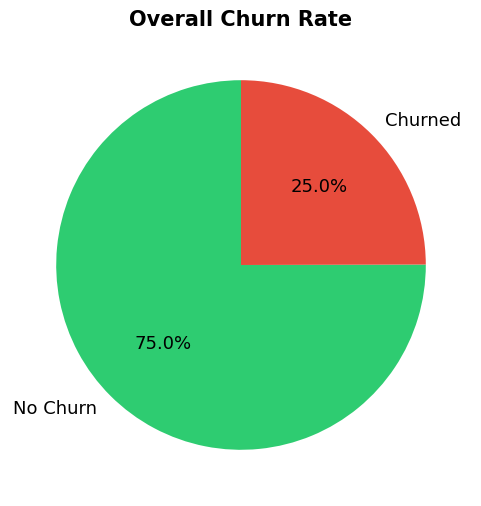

Stayed:  5,285 customers
Churned: 1,758 customers


In [15]:
# ============================================================
# PHASE 3 — EDA | Chart 1: Overall Churn Rate
# ============================================================

churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(6, 6))
plt.pie(churn_counts, labels=['No Churn', 'Churned'], colors=colors,
        autopct='%1.1f%%', startangle=90, textprops={'fontsize':13})
plt.title('Overall Churn Rate', fontsize=15, fontweight='bold')
plt.show()

print(f"Stayed:  {churn_counts['No']:,} customers")
print(f"Churned: {churn_counts['Yes']:,} customers")

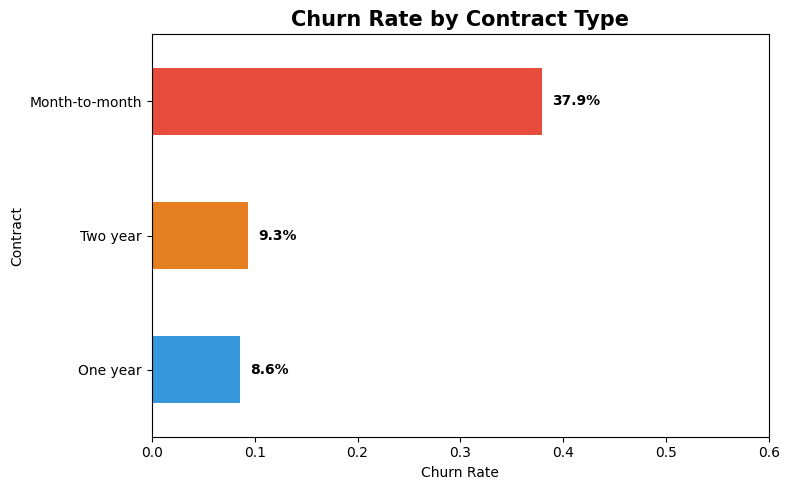

Contract
One year          0.085797
Two year          0.093268
Month-to-month    0.379496
Name: Yes, dtype: float64


In [16]:
# ============================================================
# PHASE 3 — EDA | Chart 2: Churn Rate by Contract Type
# ============================================================

contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()

plt.figure(figsize=(8, 5))
contract_churn['Yes'].sort_values().plot(kind='barh', color=['#3498db','#e67e22','#e74c3c'])
plt.title('Churn Rate by Contract Type', fontsize=15, fontweight='bold')
plt.xlabel('Churn Rate')
plt.xlim(0, 0.6)

for i, v in enumerate(contract_churn['Yes'].sort_values()):
    plt.text(v + 0.01, i, f'{v:.1%}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(contract_churn['Yes'].sort_values())

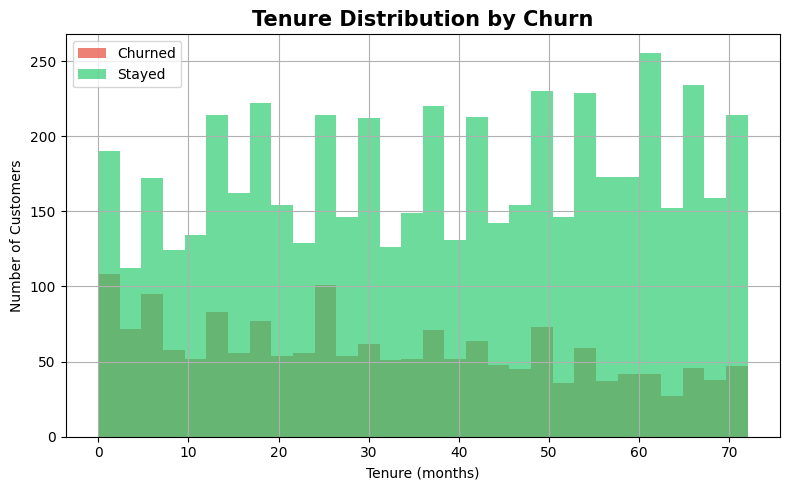

Average tenure — Churned: 31.3 months
Average tenure — Stayed: 37.4 months


In [17]:
# ============================================================
# PHASE 3 — EDA | Chart 3: Tenure Distribution by Churn
# ============================================================

plt.figure(figsize=(8, 5))

df[df['Churn']=='Yes']['tenure'].hist(bins=30, color='#e74c3c', alpha=0.7, label='Churned')
df[df['Churn']=='No']['tenure'].hist(bins=30, color='#2ecc71', alpha=0.7, label='Stayed')

plt.title('Tenure Distribution by Churn', fontsize=15, fontweight='bold')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

print("Average tenure — Churned:", round(df[df['Churn']=='Yes']['tenure'].mean(), 1), "months")
print("Average tenure — Stayed:", round(df[df['Churn']=='No']['tenure'].mean(), 1), "months")

<Figure size 700x500 with 0 Axes>

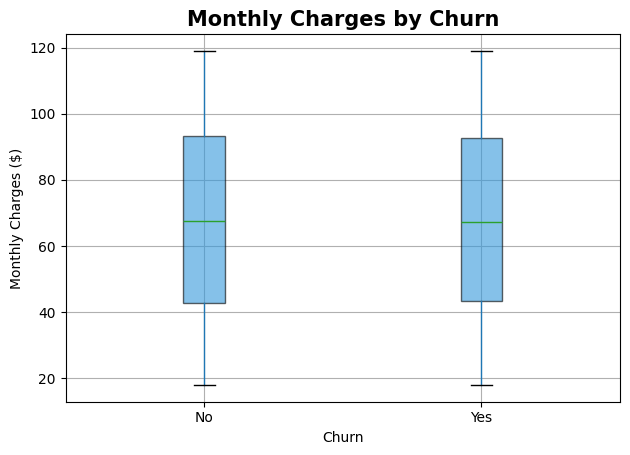

Avg Monthly Charges — Churned: 68.19
Avg Monthly Charges — Stayed: 67.96


In [18]:
# ============================================================
# PHASE 3 — EDA | Chart 4: Monthly Charges by Churn
# ============================================================

plt.figure(figsize=(7, 5))

df.boxplot(column='MonthlyCharges', by='Churn',
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.6))

plt.title('Monthly Charges by Churn', fontsize=15, fontweight='bold')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

print("Avg Monthly Charges — Churned:", round(df[df['Churn']=='Yes']['MonthlyCharges'].mean(), 2))
print("Avg Monthly Charges — Stayed:", round(df[df['Churn']=='No']['MonthlyCharges'].mean(), 2))

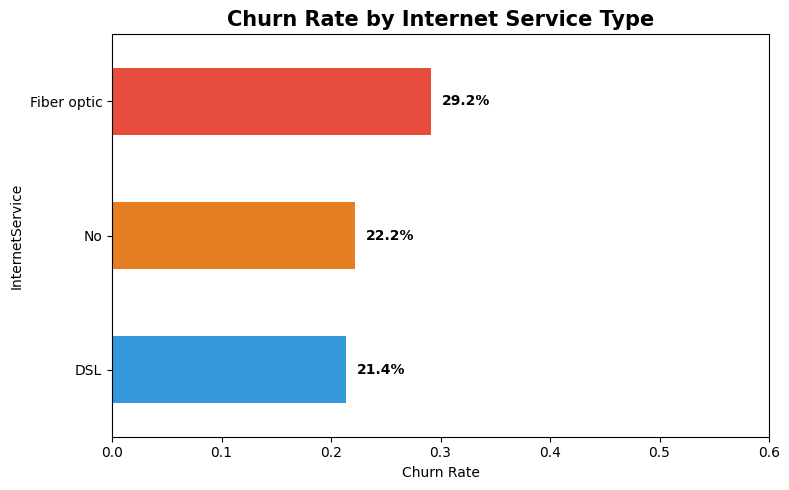

InternetService
DSL            0.213548
No             0.222005
Fiber optic    0.291640
Name: Yes, dtype: float64


In [19]:
# ============================================================
# PHASE 3 — EDA | Chart 5: Churn by Internet Service Type
# ============================================================

internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack()

plt.figure(figsize=(8, 5))
internet_churn['Yes'].sort_values().plot(kind='barh', color=['#3498db','#e67e22','#e74c3c'])
plt.title('Churn Rate by Internet Service Type', fontsize=15, fontweight='bold')
plt.xlabel('Churn Rate')
plt.xlim(0, 0.6)

for i, v in enumerate(internet_churn['Yes'].sort_values()):
    plt.text(v + 0.01, i, f'{v:.1%}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(internet_churn['Yes'].sort_values())

In [20]:
# ============================================================
# PHASE 4 — Business Insights & Recommendations
# ============================================================

insights = """
=======================================================
CUSTOMER CHURN ANALYSIS — BUSINESS INSIGHTS REPORT
=======================================================

OVERVIEW
--------
Total Customers Analysed : 7,043
Churned Customers        : 1,758 (25%)
Retained Customers       : 5,285 (75%)

-------------------------------------------------------
INSIGHT 1: Contract Type is the #1 Churn Driver
-------------------------------------------------------
- Month-to-month customers churn at 38%
- One year contracts churn at only 8.6%
- Two year contracts churn at only 9.3%

RECOMMENDATION:
Offer discounts or free add-ons to encourage
month-to-month customers to upgrade to annual contracts.
Even moving 10% of them to annual contracts would
significantly reduce overall churn.

-------------------------------------------------------
INSIGHT 2: New Customers are the Highest Risk
-------------------------------------------------------
- Churn is heavily concentrated in first 0-15 months
- After 15 months customers become much more stable
- Average tenure of churned customers: 31.3 months

RECOMMENDATION:
Launch a new customer onboarding program — proactive
check-ins, tutorials, and loyalty rewards in the first
3-6 months to build early engagement and commitment.

-------------------------------------------------------
INSIGHT 3: Price is NOT the Problem
-------------------------------------------------------
- Churned customers pay avg $68.19/month
- Retained customers pay avg $67.96/month
- Almost zero difference

RECOMMENDATION:
Do NOT focus on price cuts to reduce churn.
Focus instead on engagement, commitment, and
service quality — that is what retains customers.

-------------------------------------------------------
INSIGHT 4: Fiber Optic Needs Special Attention
-------------------------------------------------------
- Fiber optic customers churn at 29%
- Higher than DSL (21%) and No Internet (22%)
- These are premium, tech-savvy customers

RECOMMENDATION:
Introduce a fiber optic loyalty program with priority
support, speed guarantees, and competitive pricing
reviews to retain these high-value customers.

-------------------------------------------------------
OVERALL BUSINESS RECOMMENDATION
-------------------------------------------------------
Focus retention budget on:
1. Month-to-month customers → push to annual contracts
2. New customers (0-15 months) → strong onboarding
3. Fiber optic customers → loyalty & premium support

=======================================================
"""

print(insights)


CUSTOMER CHURN ANALYSIS — BUSINESS INSIGHTS REPORT

OVERVIEW
--------
Total Customers Analysed : 7,043
Churned Customers        : 1,758 (25%)
Retained Customers       : 5,285 (75%)

-------------------------------------------------------
INSIGHT 1: Contract Type is the #1 Churn Driver
-------------------------------------------------------
- Month-to-month customers churn at 38%
- One year contracts churn at only 8.6%
- Two year contracts churn at only 9.3%

RECOMMENDATION:
Offer discounts or free add-ons to encourage
month-to-month customers to upgrade to annual contracts.
Even moving 10% of them to annual contracts would
significantly reduce overall churn.

-------------------------------------------------------
INSIGHT 2: New Customers are the Highest Risk
-------------------------------------------------------
- Churn is heavily concentrated in first 0-15 months
- After 15 months customers become much more stable
- Average tenure of churned customers: 31.3 months

RECOMMENDATION:


In [21]:
# Save insights report as a text file
with open('churn_insights_report.txt', 'w') as f:
    f.write(insights)

print("✅ Report saved as churn_insights_report.txt")

✅ Report saved as churn_insights_report.txt


In [23]:
# ============================================================
# PHASE 4 — Project Summary
# ============================================================

summary = {
    'Total Customers': len(df),
    'Churned Customers': df[df['Churn']=='Yes'].shape[0],
    'Retention Rate': f"{df[df['Churn']=='No'].shape[0] / len(df):.1%}",
    'Churn Rate': f"{df[df['Churn']=='Yes'].shape[0] / len(df):.1%}",
    'Avg Tenure - Churned': f"{df[df['Churn']=='Yes']['tenure'].mean():.1f} months",
    'Avg Tenure - Stayed': f"{df[df['Churn']=='No']['tenure'].mean():.1f} months",
    'Top Churn Driver': 'Contract Type (Month-to-Month = 38%)',
    'Price Impact': 'Minimal - not a churn driver',
    'Highest Risk Segment': 'New customers (0-15 months)',
}

print("=" * 50)
print("   CUSTOMER CHURN ANALYSIS — FINAL SUMMARY")
print("=" * 50)
for key, value in summary.items():
    print(f"  {key:<30} : {value}")
print("=" * 50)
print("\n✅ Analysis Complete!")

   CUSTOMER CHURN ANALYSIS — FINAL SUMMARY
  Total Customers                : 7043
  Churned Customers              : 1758
  Retention Rate                 : 75.0%
  Churn Rate                     : 25.0%
  Avg Tenure - Churned           : 31.3 months
  Avg Tenure - Stayed            : 37.4 months
  Top Churn Driver               : Contract Type (Month-to-Month = 38%)
  Price Impact                   : Minimal - not a churn driver
  Highest Risk Segment           : New customers (0-15 months)

✅ Analysis Complete!
